# The Fourth Circle: Neural Networks, Part Four 
## Transformers IV: GPT

<br/>
Jiří Fejlek

2026-05-24
<br/>

In this project, we will have a look at another very important model based on the transformer architecture [[1](#1)]: Generative Pre-trained Transformer (GPT) [[2](#2)], which is the main building block of many large language models, such as nowadays notorious ChatGPT (https://chatgpt.com). Namely, GPT uses a *decoder* block from the original transformer architecture (unlike BERT [[3](#3)] that is based on the encoder). Consequently, GPT is more optimized for *generative* tasks. 


## Table of Contents

- [GPT Architecture](#gpt_arch)
- [Refined BookCorpus Dataset](#bookcorpus)
- [Pretraining GPT](#pretraining)
- [Fine-Tuning GPT](#fine-tuning)
- [Fine-Tuning GPT-2](#gpt-2)
- [References](#references)


## GPT Architecture <a class="anchor" id="gpt_arch"></a>

GPT architecture is based on the transformers, and hence, it looks very similar to BERT at first glance.

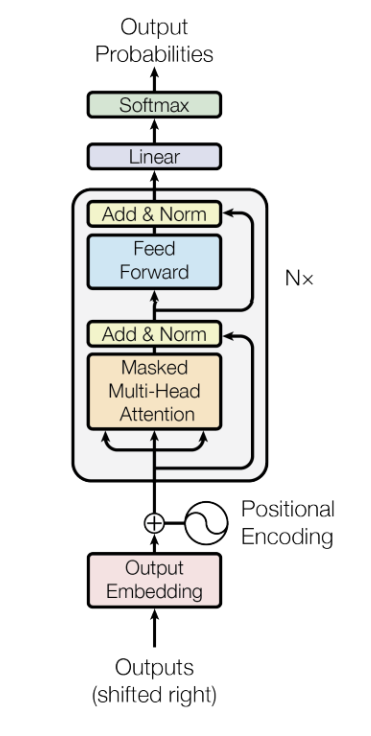

The key difference between GPT and BERT is the use of *masked* multi-head self-attention rather than regular self-attention, i.e., tokens attend only to tokens that precede them. This means that GPT models are causal in their inference (these models are usually referred to as *autoregressive*), making them more suitable for generative tasks (we cannot attend to future tokens, since they have not been generated yet). 

Let us implement a GPT-like architecture using our transformer implementation.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os
import csv

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

Let us first restate some past functions we will need.

In [3]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [4]:
def masked_softmax(X, valid_lens): 
    
    def _sequence_mask(X, valid_len, value = 0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype = torch.float32, device = X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X
        
    if valid_lens is None:
        return nn.functional.softmax(X, dim = -1)
    else:
        shape = X.shape
        
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [5]:
class DotProductAttention(nn.Module):
    
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens = None):
        
        d = queries.shape[-1]
         
        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys = number of values, k_d)
        # Values: (batch_size, number of keys = number of values, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)
        
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)

In [6]:
class MultiHeadAttention(nn.Module): 

    def transpose_qkv(self, X):
        
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
        
    def transpose_output(self, X):
        
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)
        
    def __init__(self, attention_size, num_heads, dropout, bias = False):
        
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(attention_size, bias = bias)
        self.W_k = nn.LazyLinear(attention_size, bias = bias)
        self.W_v = nn.LazyLinear(attention_size, bias = bias)
        self.W_o = nn.LazyLinear(attention_size, bias = bias)
        
    def forward(self, queries, keys, values, valid_lens):
        
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))
        
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
            
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
            
        return self.W_o(output_concat)

In [7]:
class AddNorm(nn.Module):
    
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)
    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

We will follow the more modern transformer design and will replace ReLU with GELU.

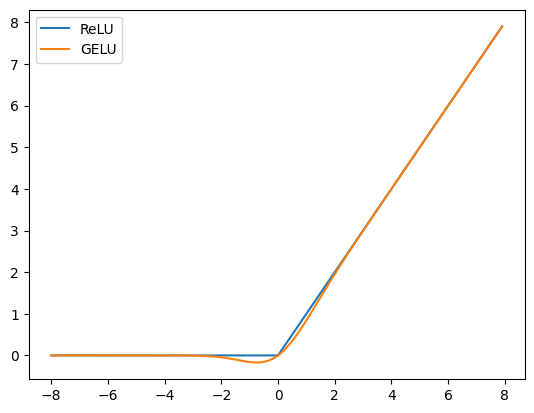

In [8]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y_relu = torch.relu(x)
y_gelu = torch.nn.functional.gelu(x)


plt.plot(x.detach(), y_relu.detach(), label="ReLU");
plt.plot(x.detach(), y_gelu.detach(), label="GELU");
plt.legend(loc="upper left");

In [9]:
class PositionWiseFFN(nn.Module): 
    
    def __init__(self, ffn_size, ffn_output_size):
        
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_size)
        self.relu = nn.GELU()
        self.dense2 = nn.LazyLinear(ffn_output_size)
        
    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

The GPT decoder is as follows. The main change from the original decoder is the absence of the encoder-decoder attention layer (since we have no encoder).

In [10]:
class TransformerDecoderBlock(nn.Module):

    def __init__(self, hidden_size, ffn_size, num_heads, dropout, use_bias = False):
        super().__init__()

        self.attention = MultiHeadAttention(hidden_size, num_heads, dropout, bias = use_bias)
        self.addnorm1 = AddNorm(hidden_size, dropout)
        self.ffn = PositionWiseFFN(ffn_size, hidden_size)
        self.addnorm2 = AddNorm(hidden_size, dropout)
        
    def forward(self, X):
        
        batch_size, num_steps, _ = X.shape
        dec_valid_lens = torch.arange(1, num_steps + 1, device = X.device).repeat(batch_size, 1)
   
        # Self-attention
        X2 = self.attention(X, X, X, dec_valid_lens)
        Y = self.addnorm1(X, X2)

        return self.addnorm2(Y, self.ffn(Y))

In [11]:
class GPTDecoder(nn.Module):

    def __init__(self, vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len = 128):
        super().__init__()
        
        self.token_embedding = nn.Embedding(vocab_size, hidden_size)
        
        # learnable positional embeddings 
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, hidden_size))

        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", TransformerDecoderBlock(hidden_size, num_heads, ffn_size, dropout, use_bias = True))
               
    def forward(self, tokens):
        
        X = self.token_embedding(tokens)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X)
        return X  

We can check our implementation.

In [12]:
vocab_size = 10000 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

decoder = GPTDecoder(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout)

tokens = torch.randint(0, vocab_size, (2, 8))
tokens

tensor([[4199, 1347, 7280, 6340,  404,  625, 1383, 1310],
        [5938, 3873, 4215, 6593, 3450, 6664, 3332, 3657]])

In [13]:
tokens.size()

torch.Size([2, 8])

In [14]:
decoded_X = decoder(tokens)
decoded_X

tensor([[[-0.2146, -1.2423,  1.0670,  ..., -0.3036, -1.3061, -1.5411],
         [ 0.2022,  1.3752,  0.6244,  ..., -1.3671, -1.6069, -0.0493],
         [ 0.4650,  0.4680, -0.9733,  ..., -1.2607,  1.0710, -1.6916],
         ...,
         [-0.9761, -0.2084,  0.5876,  ..., -0.8792, -1.7763, -1.4236],
         [ 0.9865,  0.4330, -1.4895,  ..., -0.6630,  0.5238,  0.3064],
         [-1.5510,  0.0058, -0.5506,  ..., -0.0970, -0.3743, -0.5919]],

        [[-1.5127, -0.4797, -0.4171,  ..., -1.4128, -0.0827, -1.1759],
         [-0.0267,  0.7074, -0.4106,  ..., -1.7565, -1.1131,  1.7245],
         [ 0.4266,  1.5822, -1.6428,  ..., -0.9345,  0.5577,  0.2866],
         ...,
         [ 0.6499,  0.2793, -1.0334,  ..., -0.1842, -2.5264, -0.2704],
         [ 0.9314, -0.2490, -0.3430,  ..., -0.9486,  0.1978, -0.4587],
         [ 0.6239,  1.0325, -1.0078,  ..., -0.4874, -0.6344,  0.5116]]],
       grad_fn=<NativeLayerNormBackward0>)

In [15]:
decoded_X.shape

torch.Size([2, 8, 256])

Overall, we get the following GPT model.

In [16]:
class GPTModel(nn.Module):
    
    def __init__(self, vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len = 128):
        
        super().__init__()
        self.decoder = GPTDecoder(vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len = max_len)
        self.output = nn.Sequential(nn.Dropout(dropout), nn.LazyLinear(vocab_size))

    def forward(self, tokens):
    
        decoded_X = self.decoder(tokens)

        return self.output(decoded_X)

In [17]:
vocab_size = 10000 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

gpt = GPTModel(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout)

tokens = torch.randint(0, vocab_size, (2, 8))
logits = gpt(tokens)
logits

tensor([[[ 1.6572, -0.6376, -0.8477,  ..., -0.9047,  0.3724, -0.5520],
         [-0.1085,  1.4047, -1.2037,  ..., -0.3275, -0.2745, -0.3701],
         [ 0.6049, -0.5703, -0.1206,  ..., -0.8935, -0.3941,  0.0478],
         ...,
         [ 0.1885,  0.2949, -1.0683,  ..., -0.7901,  0.8620, -0.3024],
         [ 0.5183, -0.4558,  0.3248,  ...,  0.1288,  0.0569, -0.2116],
         [ 0.8799,  0.2262,  0.9090,  ..., -0.3353, -0.8830, -0.5842]],

        [[ 1.6687, -0.2823, -0.3731,  ...,  0.3277,  0.0262, -0.5234],
         [ 0.5471,  0.9975, -0.5299,  ..., -0.3864, -0.5446,  0.1641],
         [ 0.8168, -1.0838, -0.9713,  ..., -0.1722, -0.2539,  0.9280],
         ...,
         [-0.2964, -0.7594, -0.7205,  ...,  0.3253,  0.3636, -0.3130],
         [ 1.1226, -0.6085, -0.2421,  ..., -0.6830, -0.6612, -0.9705],
         [ 1.2081,  0.2604, -0.1877,  ...,  0.0869,  0.1773, -0.9127]]],
       grad_fn=<ViewBackward0>)

In [18]:
logits.shape

torch.Size([2, 8, 10000])

In [19]:
Y = torch.arange(0,9).repeat([2,1])
Y

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8],
        [0, 1, 2, 3, 4, 5, 6, 7, 8]])

In [20]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
loss = cross_entropy_loss(logits.permute([0,2,1]), Y[:,1:])
loss

tensor([[10.0177, 10.6116,  9.8245,  9.7350,  9.7203, 10.1635,  9.8475,  9.1663],
        [ 9.6781,  9.9221,  9.0867,  9.3482,  9.6544, 10.8995,  9.3312,  8.7494]],
       grad_fn=<ViewBackward0>)

## Refined BookCorpus Dataset <a class="anchor" id="bookcorpus"></a>


Similar to our previous BERT project, the typical training of the GPT model consists of two main steps: pretraining on a large unlabelled dataset and fine-tuning for a specific task. For pretraining, we will use a subset of BooksCorpus [[4](#4)]: Refined BookCorpus Dataset from https://www.kaggle.com/datasets/nishantsingh96/refined-bookcorpus-dataset/data, which consists of 11 million paragraphs of text.

In [21]:
data_dir = "D:/nine circles 2/BookCorpus3.csv"

with open(data_dir, mode ='r') as file:
    csvFile = csv.reader(file)
    i = 0
    for lines in csvFile:
        print(lines)
        i = i + 1
        if i > 1:
            break

['0']
["she began getting up first thing in the morning. she wanted to avoid konnor and his irrational fear at having her leave him alone in the house. she'd fix a quick bite to eat for both of them, leave konnor's on the table, and then she went to dress for the day."]


Let us perform some simple text preprocessing steps.

In [22]:
lines

["she began getting up first thing in the morning. she wanted to avoid konnor and his irrational fear at having her leave him alone in the house. she'd fix a quick bite to eat for both of them, leave konnor's on the table, and then she went to dress for the day."]

In [23]:
line = re.sub('([.,!?()])', r' \1 ', str(lines))
line = re.sub('\s{2,}', ' ', line)
line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line).lower()
line

' she began getting up first thing in the morning . she wanted to avoid konnor and his irrational fear at having her leave him alone in the house . she d fix a quick bite to eat for both of them , leave konnor s on the table , and then she went to dress for the day . '

We can process the whole dataset the same way.

In [24]:
csv.field_size_limit(250000)
lines = []
with open(data_dir, mode ='r') as file:
    csvFile = csv.reader(file)
    for line in csvFile:
        line = str(line)
        line = re.sub('([.,!?()])', r' \1 ', line)
        line = re.sub('\s{2,}', ' ', line)
        line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line).lower()
        lines.append(line)     

In [25]:
lines[0]

' 0 '

In [26]:
lines[1]

' she began getting up first thing in the morning . she wanted to avoid konnor and his irrational fear at having her leave him alone in the house . she d fix a quick bite to eat for both of them , leave konnor s on the table , and then she went to dress for the day . '

The dataset indeed consists of over 11 million paragraphs.

In [27]:
len(lines)

11043120

Since we are doing this mostly for illustration purposes, we will work with merely 1 million paragraphs.

In [28]:
lines = lines[1:1000000]

The next step is to tokenize the text. We will use a simple word tokenization. We should note that the original GPT uses *Byte-Pair tokenization*(https://huggingface.co/learn/llm-course/chapter6/5), which tokenizes the text by chunks that are usually a bit smaller than individual words (the chunks are learned from the text by merging frequent pairs of tokens; the initial tokenization is a character-based tokenization). The advantage of Byte-Pair tokenization over word tokenization is that the vocabulary can be kept relatively small without the need to replace some words with *\<unk\>* tokens.

We should also note that GPT uses a single special token, *\<endoftext\>*, to separate unrelated chunks of text during pretraining (compared to BERT, which uses *\<cls\>*, *\<mask\>*, and *\<pad\>*). As we will see later, this is because GPT only performs straightforward next-token prediction during pretraining.

In [29]:
def _tokenize(text):
    return [line.split() +  ['<eot>'] for line in text]

In [30]:
lines = _tokenize(lines)

In [31]:
lines[0]

['she',
 'began',
 'getting',
 'up',
 'first',
 'thing',
 'in',
 'the',
 'morning',
 '.',
 'she',
 'wanted',
 'to',
 'avoid',
 'konnor',
 'and',
 'his',
 'irrational',
 'fear',
 'at',
 'having',
 'her',
 'leave',
 'him',
 'alone',
 'in',
 'the',
 'house',
 '.',
 'she',
 'd',
 'fix',
 'a',
 'quick',
 'bite',
 'to',
 'eat',
 'for',
 'both',
 'of',
 'them',
 ',',
 'leave',
 'konnor',
 's',
 'on',
 'the',
 'table',
 ',',
 'and',
 'then',
 'she',
 'went',
 'to',
 'dress',
 'for',
 'the',
 'day',
 '.',
 '<eot>']

We actually no longer need to separate the text into paragraphs. We can instead merge the text into one chunk.

In [32]:
lines = [token for line in lines for token in line]
len(lines)

92754056

We observe that our training dataset contains nearly 10 million tokens. 

As mentioned previously, since we are using word tokenization, we need to replace some less frequent word tokens with *\<unk\>* tokens to keep the vocabulary size manageable. 

In [33]:
vocab = Vocabulary(lines, min_freq = 50)

In [34]:
len(vocab)

39054

As the final step, we will extract text sequences from the dataset for pretraining. The length of these sequences will be the *hidden_size* (i.e., the maximum context length) plus 1 (the last token serves as a reference for the last prediction). Since all chunks of text have the same length, we do not need to perform padding (hence, the absence of a padding token).

In [35]:
lines = vocab[lines]

In [36]:
n = 156
lines = [lines[i:i + n] for i in range(0, len(lines), n)]

In [37]:
len(lines[1])

156

In [38]:
len(lines[2])

156

In [39]:
len(lines[-2])

156

In [40]:
len(lines[-1])

44

In [41]:
del lines

Overall, we obtain the following *BookCorpus* class, which prepares the dataset for pretraining.

In [42]:
class BookCorpus:
    
    def _read(self):

        data_dir = self.data_dir      
        lines = []
        
        with open(data_dir, mode ='r') as file:
            csvFile = csv.reader(file)
            i = 0
            for line in csvFile:
                line = str(line)
                line = re.sub('([.,!?()])', r' \1 ', line)
                line = re.sub('\s{2,}', ' ', line)
                line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line).lower()
                lines.append(line) 
                i = i + 1
                if i > self.max_paragraphs + 1:
                    break
                
        return lines[1:]

    def _tokenize(self, lines):
        tokens = [line.split() +  ['<eot>'] for line in lines]
        tokens = [token for line in tokens for token in line]
        return tokens

    def _build(self, vocab = None): # built vocabulary

        data_dir = self.data_dir
        lines = self._read()
        tokens = self._tokenize(lines)
        
        if vocab is None: 
            vocab = Vocabulary(tokens, min_freq = 50)

        corpus = vocab[tokens]
        return corpus, vocab

    def __init__(self, data_dir, batch_size, max_len, max_paragraphs, vocab = None):  
        
        self.data_dir = data_dir
        self.max_len = max_len
        self.max_paragraphs = max_paragraphs

        
        if vocab is None: 
            train_corpus, self.vocab = self._build() 
        else:
            self.vocab = vocab
            train_corpus, _  = self._build(vocab = self.vocab)

        train_corpus_split = [train_corpus[i:i + max_len] for i in range(0, len(train_corpus), max_len)]
        train_corpus_split = train_corpus_split[:-1]
            
        self.dataset = torch.utils.data.TensorDataset(torch.tensor(train_corpus_split))
        self.train_dataloader = torch.utils.data.DataLoader(self.dataset, batch_size, shuffle = True)  

In [43]:
BookCorpus_dataset = BookCorpus(data_dir = "D:/nine circles 2/BookCorpus3.csv", max_len = 129, max_paragraphs = 1000000, batch_size = 50)

Dataset with *batch_size* = 50 consists of about 15 thousand batches.

In [44]:
len(BookCorpus_dataset.train_dataloader)

14381

Let us check the evaluation of the GPT model on a batch.

In [45]:
for X in BookCorpus_dataset.train_dataloader:
    break

In [46]:
X[0].size()

torch.Size([50, 129])

In [47]:
vocab_size = len(BookCorpus_dataset.vocab) 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

gpt = GPTModel(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout, max_len = 128)

In [48]:
X[0][:,:-1].size()

torch.Size([50, 128])

In [49]:
logits = gpt(X[0][:,:-1])
logits.size()

torch.Size([50, 128, 39054])

In [50]:
X[0][:,1:].size()

torch.Size([50, 128])

We can evaluate the predicted tokens using the standard cross-entropy loss.

In [51]:
cross_entropy_loss = nn.CrossEntropyLoss()
cross_entropy_loss(logits.permute([0,2,1]), X[0][:,1:])

tensor(10.7260, grad_fn=<NllLoss2DBackward0>)

## Pretraining GPT <a class="anchor" id="pretraining"></a>

We have everything ready to pretrain a GPT model. Pretraining GPT is much more straightforward than pretraining BERT; it is based on next-token prediction, which we already know from our projects with simple RNNs. Hence, the training loop is as follows. 

In [52]:
def gpt_pretrain_loop_cuda(train_data_loader, model, loss_fn, optimizer, max_norm, max_iter):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    loss_sum_history = []

    i = 1

    while True:
        
        for batch, X in enumerate(train_data_loader):

            X = X[0].to(cuda_device)

            X_input = X[:,:-1]
            X_pred = X[:,1:]

            optimizer.zero_grad() # zero out the gradients
        
            pred_logits = model(X_input) # forward pass
        
            loss = loss_fn(pred_logits.permute([0,2,1]), X_pred) # loss evaluation 

            # Backpropagation
            loss.backward() # gradient evaluation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
            optimizer.step() # SGD step
        

            # compute prediction epoch loss and accuracy
            with torch.no_grad(): # we do not need to compute the gradients
                loss_sum_train = loss_sum_train + loss*len(X)
                size_train = size_train + len(X)


            if i % 100 == 0:
                with torch.no_grad():
                    loss_sum_history.append(loss_sum_train/size_train)
                    loss_sum_train  = 0
                    size_train = 0

            if i > max_iter:
                break

            i = i + 1
        
        if i > max_iter:
                break
    
    return  loss_sum_history

We should note that the loop terminates after performing gradient descent for a given number of batches (rather than after a given number of epochs). This is because training GPT takes much longer than training BERT. This is because BERT predicts merely 15% of masked tokens, whereas GPT predicts *all* tokens.

Our two-block GPT model with 128 context length has over 20 million parameters.

In [53]:
sum(p.numel() for p in gpt.parameters() if p.requires_grad)

20600470

To reduce computational time, we will go through merely 30,000 batches.

In [54]:
torch.manual_seed(123)
batch_size = 50
train_dataloader = torch.utils.data.DataLoader(BookCorpus_dataset.dataset, batch_size, shuffle = True)  

gpt = gpt.to(cuda_device)

max_iter = 50000
max_norm = 100
optim_SGD_cuda = torch.optim.Adam(gpt.parameters(), lr=0.001)
cross_entropy_loss = nn.CrossEntropyLoss()

start = time.time()
loss_epochs  = gpt_pretrain_loop_cuda(train_dataloader, gpt, cross_entropy_loss, optim_SGD_cuda, max_norm, max_iter) 
end = time.time()
print(end - start)

4499.677185058594


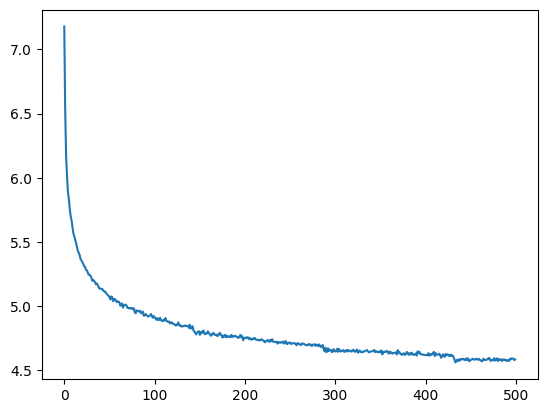

In [55]:
plt.plot([x.cpu() for x in loss_epochs]);

Let us save our pretrained model.

In [56]:
torch.save(gpt.state_dict(), 'D:/nine circles 2/gpt')

In [57]:
vocab_size = len(BookCorpus_dataset.vocab) 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

gpt = GPTModel(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout, max_len = 128).to(cuda_device)
gpt.load_state_dict(torch.load('D:/nine circles 2/gpt', weights_only=True))

<All keys matched successfully>

## Fine-Tuning GPT <a class="anchor" id="fine-tuning"></a>

Let us now demonstrate fine-tuning. We will consider the task of fine-tuning GPT to make a chatbot. Namely, we will consider the 3K Conversations Dataset for ChatBot (https://www.kaggle.com/datasets/kreeshrajani/3k-conversations-dataset-for-chatbot/code), which consists of three thousand simple conversations (question and answer).

In [58]:
data_dir = "D:/nine circles 2/Conversation.csv"

with open(data_dir, mode ='r') as file:
    csvFile = csv.reader(file)
    
    lines = []
    
    for line in csvFile:
        line = str(line)
        line = re.sub('([.,!?()])', r' \1 ', line)
        line = re.sub('\s{2,}', ' ', line)
        line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line).lower()
        lines.append(line)

lines = lines[1:]

The questions and answers are separated by commas.

In [59]:
lines[0].split(",")

[' 0 ', ' hi ', ' how are you doing ? ', ' i m fine . how about yourself ? ']

We will rewrite the conversations into the following format.

In [60]:
'question .' + lines[0].split(",")[1] + 'answer .' + lines[0].split(",")[2]

'question . hi answer . how are you doing ? '

In [61]:
for i in range(len(lines)):
    line = lines[i].split(",")
    line = 'question .' + line[1] + 'answer .' + line[2]
    lines[i] = line

In [62]:
lines[:10]

['question . hi answer . how are you doing ? ',
 'question . i m fine . how about yourself ? answer . i m pretty good . thanks for asking . ',
 'question . i m pretty good . thanks for asking . answer . no problem . so how have you been ? ',
 'question . no problem . so how have you been ? answer . i ve been great . what about you ? ',
 'question . i ve been great . what about you ? answer . i ve been good . i m in school right now . ',
 'question . i ve been good . i m in school right now . answer . what school do you go to ? ',
 'question . what school do you go to ? answer . i go to pcc . ',
 'question . i go to pcc . answer . do you like it there ? ',
 'question . do you like it there ? answer . it s okay . it s a really big campus . ',
 'question . it s okay . it s a really big campus . answer . good luck with school . ']

Hence, the input into model will be of the from *'question. i m fine answer.'* and the goal of the model will be to generate the continuation.

In [63]:
len(lines)

3725

The dataset class will be as follows. Notice that we need to use the vocabulary obtained from our pretrained dataset. We should also note that the input sequences into the model will now be separate conversations, i.e., we need to use padding during training. For that purpose, we will use the *\<eot\>* token. 

In [64]:
class Conversations:
    
    def _read(self):

        data_dir = self.data_dir      
        lines_1 = []
        lines_2 = []
        
        with open(data_dir, mode ='r') as file:
            csvFile = csv.reader(file)
            
            for line in csvFile:
                line = str(line)
                line = re.sub('([.,!?()])', r' \1 ', line)
                line = re.sub('\s{2,}', ' ', line)
                line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line).lower()
                lines_1.append(line)
                lines_2.append(line)
                
        for i in range(len(lines_1)):
            line = lines_1[i].split(",")
            lines_1[i] = 'question .' + line[1] + 'answer .'
            lines_2[i] = line[2]
            
        return lines_1[1:], lines_2[1:]

    def _tokenize(self, lines_1, lines_2):
        tokens_1 = [line.split() for line in lines_1]
        tokens_2 = [line.split() for line in lines_2]

        valid_lens_1 = [len(token) for token in tokens_1]
        valid_lens_2 = [len(token) for token in tokens_2]
        
        tokens = [tokens_1[i] +  tokens_2[i] for i in range(len(tokens_1))]
        tokens = [self.truncate_pad(line, '<eot>') for line in tokens]
        
        return tokens, valid_lens_1, valid_lens_2

    def _build(self, vocab = None): # built vocabulary

        data_dir = self.data_dir
        lines_1, lines_2 = self._read()
        tokens, valid_lens_1, valid_lens_2 = self._tokenize(lines_1, lines_2)

        if vocab is None: 
            vocab = Vocabulary(tokens, min_freq = 1)

        corpus = vocab[tokens]
        return corpus, valid_lens_1, valid_lens_2, vocab

    def truncate_pad(self, line, padding_token):
        num_steps = self.max_len
        if len(line) > num_steps:
            return line[:num_steps] # Truncate
        return line + [padding_token] * (num_steps - len(line)) # Pad

    def __init__(self, data_dir, batch_size, max_len, vocab):  
        
        self.data_dir = data_dir
        self.max_len = max_len

        
        self.vocab = vocab
        corpus, valid_lens_1, valid_lens_2, _  = self._build(vocab = self.vocab)

        self.dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(corpus[:3500]), torch.tensor(valid_lens_1[:3500]), torch.tensor(valid_lens_2[:3500])])
        self.dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(corpus[3500:]), torch.tensor(valid_lens_1[3500:]), torch.tensor(valid_lens_2)[3500:]])
        self.train_dataloader = torch.utils.data.DataLoader(self.dataset_train, batch_size, shuffle = True)  
        self.test_dataloader = torch.utils.data.DataLoader(self.dataset_test, batch_size, shuffle = False)  

In [65]:
Conversations_dataset = Conversations(data_dir = "D:/nine circles 2/Conversation.csv", max_len = 129, batch_size = 50, vocab = BookCorpus_dataset.vocab)

Let us check our implementation. 

In [66]:
Conversations_dataset.dataset_train[1]

(tensor([28040,     1, 17275, 21163, 13513,     1, 17005,   952, 38893,   830,
          2321,     1, 17275, 21163, 27198, 15223,     1, 34981, 13954,  2917,
             1,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,  

In [67]:
Conversations_dataset.dataset_test[1]

(tensor([28040,     1, 10785, 34358,  3987, 16608,   830, 38165, 34992, 36281,
          1391, 34760, 38885,  2321,     1, 34992, 24712, 18781, 36113,     1,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,   829,   829,   829,   829,
           829,   829,   829,   829,   829,   829,  

In [68]:
Conversations_dataset.vocab.to_tokens(Conversations_dataset.dataset_train[1][0])[:25]

['question',
 '.',
 'i',
 'm',
 'fine',
 '.',
 'how',
 'about',
 'yourself',
 '<unk>',
 'answer',
 '.',
 'i',
 'm',
 'pretty',
 'good',
 '.',
 'thanks',
 'for',
 'asking',
 '.',
 '<eot>',
 '<eot>',
 '<eot>',
 '<eot>']

In [69]:
Conversations_dataset.vocab.to_tokens(Conversations_dataset.dataset_train[1][0][Conversations_dataset.dataset_train[1][1]:Conversations_dataset.dataset_train[1][1]+Conversations_dataset.dataset_train[1][2]])

['i', 'm', 'pretty', 'good', '.', 'thanks', 'for', 'asking', '.']

In [70]:
for X, Y_len_1, Y_len_2 in Conversations_dataset.train_dataloader:
    break

In [71]:
logits = gpt(X[:,:-1].to(cuda_device))

Since we are using padding, we need to use a masked loss (to ignore loss of padding predictions). In this implementation, we also masked the input questions' predictions, since we are only interested in predicting answers. 

In [72]:
def masked_loss(loss, Y_hat, Y, Y_len_1, Y_len_2):
    
    loss_all = cross_entropy_loss(Y_hat, Y[:,1:])
    loss = 0

    for i in range(loss_all.size()[0]):
        loss = loss + (loss_all[i][Y_len_1[i]-1:Y_len_1[i]+Y_len_2[i]-1]).mean()

    return loss/len(Y)

In [73]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction = 'none')
masked_loss(cross_entropy_loss, logits.permute([0,2,1]), X.to(cuda_device),Y_len_1.to(cuda_device),Y_len_2.to(cuda_device))

tensor(4.4418, device='cuda:0', grad_fn=<DivBackward0>)

Since we are performing fine-tuning, we can also freeze some layers. Namely, we will freeze the token embeddings.

In [74]:
gpt

GPTModel(
  (decoder): GPTDecoder(
    (token_embedding): Embedding(39054, 256)
    (blks): Sequential(
      (0): TransformerDecoderBlock(
        (attention): MultiHeadAttention(
          (attention): DotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (W_o): Linear(in_features=256, out_features=256, bias=True)
        )
        (addnorm1): AddNorm(
          (dropout): Dropout(p=0.1, inplace=False)
          (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
        (ffn): PositionWiseFFN(
          (dense1): Linear(in_features=256, out_features=4, bias=True)
          (relu): GELU(approximate='none')
          (dense2): Linear(in_features=4, out_features=256, bias=True)
        )
        (addnorm2): AddNorm(
    

In [75]:
for param in gpt.decoder.token_embedding.parameters():
    param.requires_grad = False

Our fine-tuning loop is as follows.

In [76]:
def gpt_train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, valid_lens_1, valid_lens_2) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        valid_lens_1 = valid_lens_1.to(cuda_device)
        valid_lens_2 = valid_lens_2.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X[:,:-1]) # forward pass
        loss = masked_loss(loss_fn, pred_logits.permute([0,2,1]), X, valid_lens_1, valid_lens_2) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        
        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, valid_lens_1_test, valid_lens_2_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            valid_lens_1_test = valid_lens_1_test.to(cuda_device)
            valid_lens_2_test = valid_lens_2_test.to(cuda_device)
            
            pred_logits_test = model(X_test[:,:-1])
            loss_sum_test = loss_sum_test + masked_loss(loss_fn, pred_logits_test.permute([0,2,1]), X_test, valid_lens_1_test, valid_lens_2_test)*len(X_test)
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train, loss_sum_test.detach(), learning_rate[0]

Let us fine-tune our model.

In [77]:
torch.manual_seed(123)

n_epochs = 30
max_norm = 100

Conversations_dataset = Conversations(data_dir = "D:/nine circles 2/Conversation.csv", max_len = 129, batch_size = 25, vocab = BookCorpus_dataset.vocab)
Conversations_dataset_train_loader = Conversations_dataset.train_dataloader
Conversations_dataset_test_loader = Conversations_dataset.test_dataloader

cross_entropy_loss = nn.CrossEntropyLoss(reduction = 'none')

optim_SGD_cuda = torch.optim.Adam(gpt.parameters(), lr = 0.00001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20], gamma = 0.1)


loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]  = gpt_train_test_loop_cuda(Conversations_dataset_train_loader, Conversations_dataset_test_loader, gpt, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

338.8511085510254


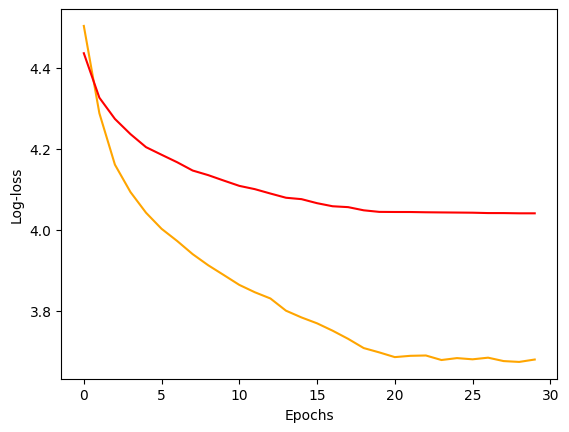

In [78]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [79]:
loss_epochs_train.min()

3.6736176013946533

In [80]:
loss_epochs_test.min()

4.040775775909424

To generate new answers, we need to implement some prediction strategy (from our previous projects, we know of greedy search and beam search). Let us implement a simple greedy search. Let us assume the first question from the test set.

In [81]:
question = BookCorpus_dataset.vocab.to_tokens(Conversations_dataset.dataset_test[1][0][:Conversations_dataset.dataset_test[1][1]])
question

['question',
 '.',
 'don',
 't',
 'believe',
 'him',
 '<unk>',
 'whatever',
 'the',
 'tv',
 'ads',
 'tell',
 'you',
 'answer',
 '.']

The answer in the dataset is as follows.

In [82]:
answer = BookCorpus_dataset.vocab.to_tokens(Conversations_dataset.dataset_test[1][0][Conversations_dataset.dataset_test[1][1]:])[:10]
answer

['the',
 'opposite',
 'is',
 'true',
 '.',
 '<eot>',
 '<eot>',
 '<eot>',
 '<eot>',
 '<eot>']

Let us tokenize the question and pad it to the correct size (we actually would not need to do that in a more efficient implementation of GPT, since the model does not attend to padding tokens due to causality anyway). 

In [83]:
x_input = Conversations_dataset.dataset_test[1][0][:Conversations_dataset.dataset_test[1][1]]
x_input

tensor([28040,     1, 10785, 34358,  3987, 16608,   830, 38165, 34992, 36281,
         1391, 34760, 38885,  2321,     1])

In [84]:
len(x_input)

15

In [85]:
padding = (torch.ones(128)*BookCorpus_dataset.vocab['<eot>']).long()
padding

tensor([829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829, 829,
        829, 829])

In [86]:
padding[:len(x_input)] = x_input

In [87]:
padding.size()

torch.Size([128])

Let us compute the predicted logits and extract the predictions for the last token of the unpadded sequence.

In [88]:
pred_logits = gpt(padding.to(cuda_device))
pred_logits.size()

torch.Size([1, 128, 39054])

In [89]:
Conversations_dataset.dataset_test[1][1]

tensor(15)

Using a greedy strategy, we would predict the following token.

In [90]:
pred_logits[:,Conversations_dataset.dataset_test[1][1]-1,:].argmax()

tensor(17275, device='cuda:0')

Let us have a look at the whole response.

In [91]:
def predict_greedy(model, input_X, max_length, num_steps):
    
    
    with torch.no_grad():
        
        ouput = (torch.ones(max_length)*BookCorpus_dataset.vocab['<eot>']).long().to(cuda_device)
        len_x = len(input_X)
        ouput[:len_x] = input_X
        
        for i in range(num_steps):
            new_output = model(ouput)
            new_output = new_output[:,len_x-1,:].argmax()
            
            ouput[len_x] = new_output
            len_x = len_x + 1
            
        return ouput.flatten()

In [94]:
prediction = predict_greedy(gpt, Conversations_dataset.dataset_test[1][0][:Conversations_dataset.dataset_test[1][1]].to(cuda_device), 128, 10)

In [96]:
BookCorpus_dataset.vocab.to_tokens(prediction[:10+len(Conversations_dataset.dataset_test[1][0][:Conversations_dataset.dataset_test[1][1]])])

['question',
 '.',
 'don',
 't',
 'believe',
 'him',
 '<unk>',
 'whatever',
 'the',
 'tv',
 'ads',
 'tell',
 'you',
 'answer',
 '.',
 'i',
 'm',
 'going',
 'to',
 'get',
 'a',
 'lot',
 'of',
 'tv',
 '.']

We got a a bit weird response, although,  it is at least related to the topic. 

To demonstrate that pretraining was an important step in training our GPT model. Let us now train the same GPT model from scratch on the 3K Conversations Dataset.

In [97]:
torch.manual_seed(123)

vocab_size = len(BookCorpus_dataset.vocab) 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

gpt = GPTModel(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout, max_len = 128).to(cuda_device)

n_epochs = 30
max_norm = 100

Conversations_dataset = Conversations(data_dir = "D:/nine circles 2/Conversation.csv", max_len = 129, batch_size = 25, vocab = BookCorpus_dataset.vocab)
Conversations_dataset_train_loader = Conversations_dataset.train_dataloader
Conversations_dataset_test_loader = Conversations_dataset.test_dataloader

cross_entropy_loss = nn.CrossEntropyLoss(reduction = 'none')

optim_SGD_cuda = torch.optim.Adam(gpt.parameters(), lr = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20], gamma = 0.1)


loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]  = gpt_train_test_loop_cuda(Conversations_dataset_train_loader, Conversations_dataset_test_loader, gpt, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

348.42510080337524


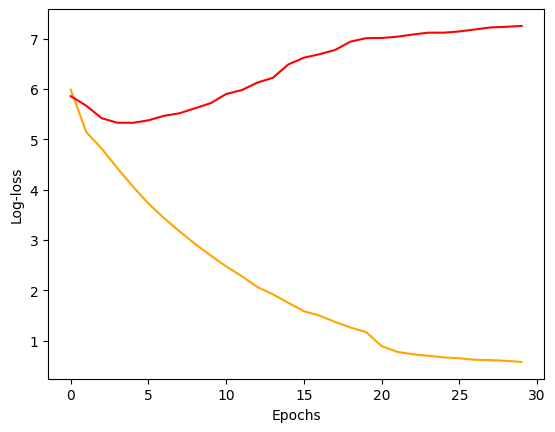

In [98]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [99]:
loss_epochs_train.min()

0.576097846031189

In [100]:
loss_epochs_test.min()

5.32915735244751

We have obtained a much worse model in terms of log-loss. Mainly, we notice that the model appears much more susceptible to overfitting than our fine-tuned model. 

## Fine-Tuning GPT-2 <a class="anchor" id="gpt-2"></a>

As the final step of our project, let us fine-tune the GPT-2 model (https://huggingface.co/openai-community/gpt2) on the 3K Conversations Dataset for ChatBot. We can download the model as follows.

In [101]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [102]:
gpt = GPT2LMHeadModel.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [103]:
gpt

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

The architecture is very similar to our GPT model. One interesting difference is the positions of layer normalizations (before the attention mechanism and linear layers instead of after). This innovation emerged after the introduction of the original transformer architecture. It turns out that the first layer normalization before the blocks leads to smaller initial gradients and, hence, to easier learning [[5](#5)].

The GPT-2 model has over 120 million parameters.

In [104]:
sum(p.numel() for p in gpt.parameters() if p.requires_grad)

124439808

We will disable KV-caching to save some memory requirements to run the model.

In [105]:
gpt.config.use_cache

True

In [106]:
gpt.config.use_cache = False

In [107]:
gpt.config.use_cache

False

We need to tokenize our dataset using the GPT-2 tokenizer.

In [108]:
gpt_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

Since we need padding, we need to specify the padding token (remember that GPT does not use padding during pretraining).

In [109]:
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

In [110]:
tokenized = gpt_tokenizer(['Hello! How are you? ', 'I'], return_tensors="pt", padding = 'max_length') # pt = pytorch.tensor
tokenized

{'input_ids': tensor([[15496,     0,  1374,  ..., 50256, 50256, 50256],
        [   40, 50256, 50256,  ..., 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]])}

In [111]:
tokenized.input_ids.size()

torch.Size([2, 1024])

We can check that 50256 indeed corresponds to *\<eot>\*.

In [112]:
gpt_tokenizer(['<|endoftext|>']).input_ids[0]

[50256]

Overall, we get the following dataset class.

In [113]:
class Conversations2:
    
    def _read_tokenize(self):

        data_dir = self.data_dir


        data_dir = self.data_dir  
        lines = []
        input_ids = []
        attention_masks = []
        valid_lens_1 = []
        valid_lens_2 = []
        
        with open(data_dir, mode ='r') as file:
            csvFile = csv.reader(file)
            
            for line in csvFile:
                line = str(line)
                line = re.sub('([.,!?()])', r' \1 ', line)
                line = re.sub('\s{2,}', ' ', line)
                line = re.sub('[^0-9A-Za-z.,!?]+', ' ',line)
                lines.append(line)

        lines = lines[1:]
        
        for i in range(len(lines)):
            line = lines[i].split(",")
            
            lines_1 = 'question .' + line[1] + 'answer .'
            lines_2 = line[2]
            
            
            lines_1 = gpt_tokenizer(lines_1, return_tensors="pt").input_ids.flatten()
            lines_2 = gpt_tokenizer(lines_2, return_tensors="pt").input_ids.flatten()

            valid_lens_1.append(len(lines_1))
            valid_lens_2.append(len(lines_2))

            line = torch.cat([lines_1, lines_2],0)
            attention_mask = torch.cat([torch.ones(len(line)),torch.zeros(self.max_len-len(line))])
            line = torch.cat([line, gpt_tokenizer(['<|endoftext|>']).input_ids[0][0]*torch.ones(self.max_len-len(line))]).long()

            input_ids.append(line)
            attention_masks.append(attention_mask)
 
        return input_ids, attention_masks, valid_lens_1, valid_lens_2

    def __init__(self, data_dir, batch_size, max_len):  
        
        self.data_dir = data_dir
        self.max_len = max_len


        input_ids, attention_masks, valid_lens_1, valid_lens_2 = self._read_tokenize() 
        
        self.dataset_train = torch.utils.data.TensorDataset(*[torch.stack(input_ids[:3500]), torch.stack(attention_masks[:3500]), torch.tensor(valid_lens_1[:3500]), torch.tensor(valid_lens_2[:3500])])
        self.dataset_test = torch.utils.data.TensorDataset(*[torch.stack(input_ids[3500:]), torch.stack(attention_masks)[3500:], torch.tensor(valid_lens_1)[3500:], torch.tensor(valid_lens_2)[3500:]])

        self.train_dataloader = torch.utils.data.DataLoader(self.dataset_train, batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(self.dataset_test, batch_size, shuffle = False) 

In [114]:
Conversations_dataset = Conversations2(data_dir = "D:/nine circles 2/Conversation.csv", batch_size = 4, max_len = 127)

In [115]:
Conversations_dataset.dataset_train[0]

(tensor([25652,   764, 23105,  3280,   764,   703,   389,   345,  1804,  5633,
           220, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 5

In [116]:
Conversations_dataset.dataset_train[0][0]

tensor([25652,   764, 23105,  3280,   764,   703,   389,   345,  1804,  5633,
          220, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256])

The inputs into the model are token sequences and attention masks (that denote padding).

In [117]:
Conversations_dataset.dataset_train[0][0][:Conversations_dataset.dataset_train[0][2]+Conversations_dataset.dataset_train[0][3]+1]

tensor([25652,   764, 23105,  3280,   764,   703,   389,   345,  1804,  5633,
          220, 50256])

In [118]:
Conversations_dataset.dataset_train[0][1][:Conversations_dataset.dataset_train[0][2]+Conversations_dataset.dataset_train[0][3]+1]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.])

Let us check the evaluation.

In [119]:
for input_id, attention_mask, Y_len_1, Y_len_2 in Conversations_dataset.train_dataloader:
    break

In [120]:
gpt = gpt.to(cuda_device)

In [121]:
input_id = input_id.flatten(1).to(cuda_device)
attention_mask = attention_mask.flatten(1).to(cuda_device)

with torch.no_grad():
    output_x = gpt(input_ids = input_id[:,:-1], attention_mask = attention_mask[:,:-1])
    output_x

In [122]:
output_x.logits.size()

torch.Size([4, 126, 50257])

We will again freeze embedding layers.

In [123]:
gpt

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [124]:
for param in gpt.transformer.wte.parameters():
    param.requires_grad = False

In [125]:
for param in gpt.transformer.wpe.parameters():
    param.requires_grad = False

In [126]:
sum(p.numel() for p in gpt.parameters() if p.requires_grad)

85056000

That reduces the number of trainable parameters by 40 million.

In [127]:
def gpt_train_test_loop_cuda2(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (input_id, attention_mask, valid_lens_1, valid_lens_2) in enumerate(train_data_loader):

        input_id = input_id.to(cuda_device)
        attention_mask = attention_mask.to(cuda_device)
        valid_lens_1 = valid_lens_1.to(cuda_device)
        valid_lens_2 = valid_lens_2.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(input_ids = input_id[:,:-1], attention_mask = attention_mask[:,:-1]).logits # forward pass
        loss = masked_loss(loss_fn, pred_logits.permute([0,2,1]), input_id, valid_lens_1, valid_lens_2) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        
        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(input_id)
            size_train = size_train + len(input_id)

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (input_id_test, attention_mask_test, valid_lens_1_test, valid_lens_2_test) in enumerate(test_data_loader):

            input_id_test = input_id_test.to(cuda_device)
            attention_mask_test = attention_mask_test.to(cuda_device)
            valid_lens_1_test = valid_lens_1_test.to(cuda_device)
            valid_lens_2_test = valid_lens_2_test.to(cuda_device)
            
            pred_logits_test = model(input_ids = input_id_test[:,:-1], attention_mask = attention_mask_test[:,:-1]).logits
            loss_sum_test = loss_sum_test + masked_loss(loss_fn, pred_logits_test.permute([0,2,1]), input_id_test, valid_lens_1_test, valid_lens_2_test)*len(input_id_test)
            size_test = size_test + len(input_id_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

We are ready to fine-tune the GPT-2 model.

In [128]:
Conversations_dataset =  Conversations2(data_dir = "D:/nine circles 2/Conversation.csv", batch_size = 16, max_len = 127)
Conversations_dataset_train_loader = Conversations_dataset.train_dataloader
Conversations_dataset_test_loader = Conversations_dataset.test_dataloader

In [129]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction = 'none')

n_epochs = 10
max_norm = 100
optim_SGD_cuda = torch.optim.Adam(gpt.parameters(), lr = 0.00001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[10], gamma = 0.1)


loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]  = gpt_train_test_loop_cuda2(Conversations_dataset_train_loader, Conversations_dataset_test_loader, gpt, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

396.157408952713


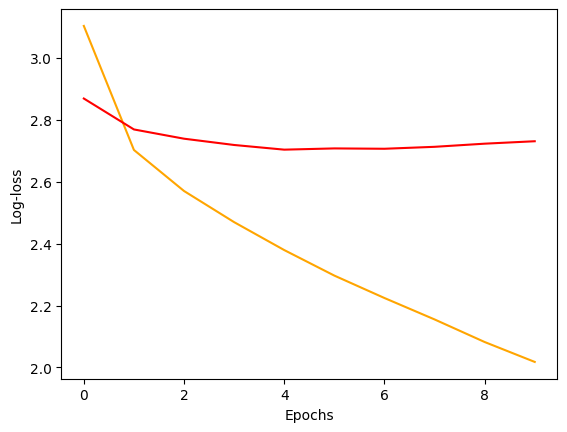

In [130]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [131]:
loss_epochs_train.min()

2.018008232116699

In [132]:
loss_epochs_test.min()

2.703669309616089

We have achieved a substantially lower log-loss than our smaller model, demonstrating the benefit of pretraining on vast amounts of data. Let us check the predictions.

In [133]:
with torch.no_grad():
    inputs = gpt_tokenizer("question . Do you believe him  ? answer .", return_tensors="pt").to(cuda_device)
    outputs = gpt.generate(**inputs, max_new_tokens=10, num_beams=2)
    dec_output = gpt_tokenizer.batch_decode(outputs, skip_special_tokens=True)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Note that \xa0 is just a character for a space.

In [134]:
dec_output

['question . Do you believe him  ? answer . of course . \xa0I believe him  ']

We can demonstrate that our fine-tuning has ingrained our choice of formatting into the model. Provided that we set the input without *'question .'*, we get no output.

In [135]:
with torch.no_grad():
    inputs = gpt_tokenizer("question . How are you today  ?", return_tensors="pt").to(cuda_device)
    outputs = gpt.generate(**inputs, max_new_tokens=10, num_beams=2)
    dec_output = gpt_tokenizer.batch_decode(outputs, skip_special_tokens=True)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [136]:
dec_output

['question . How are you today  ?          ']

In [137]:
with torch.no_grad():
    inputs = gpt_tokenizer("question . How are you today ? answer .", return_tensors="pt").to(cuda_device)
    outputs = gpt.generate(**inputs, max_new_tokens=10, num_beams=2)
    dec_output = gpt_tokenizer.batch_decode(outputs, skip_special_tokens=True)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [138]:
dec_output

['question . How are you today ? answer . well \xa0i m doing well .  ']

## References <a class="anchor" id="references"></a>


<a id="1">[1]</a> VASWANI, Ashish, et al. Attention is all you need. *Advances in neural information processing systems*, 2017, 30.

<a id="2">[2]</a> RADFORD, Alec, et al. Improving language understanding by generative pre-training. 2018.

<a id="3">[3]</a> DEVLIN, Jacob, et al. Bert: Pre-training of deep bidirectional transformers for language understanding. In: *Proceedings of the 2019 conference of the North American chapter of the association for computational linguistics: human language technologies, volume 1 (long and short papers).* 2019. p. 4171-4186.

<a id="4">[4]</a> ZHU, Yukun, et al. Aligning books and movies: Towards story-like visual explanations by watching movies and reading books. In: *Proceedings of the IEEE international conference on computer vision.* 2015. p. 19-27.

<a id="5">[5]</a> XIONG, Ruibin, et al. On layer normalization in the transformer architecture. In: *International conference on machine learning.* PMLR, 2020. p. 10524-10533.